# In-Depth Analysis of Nvidia’s Customer Landscape 💻

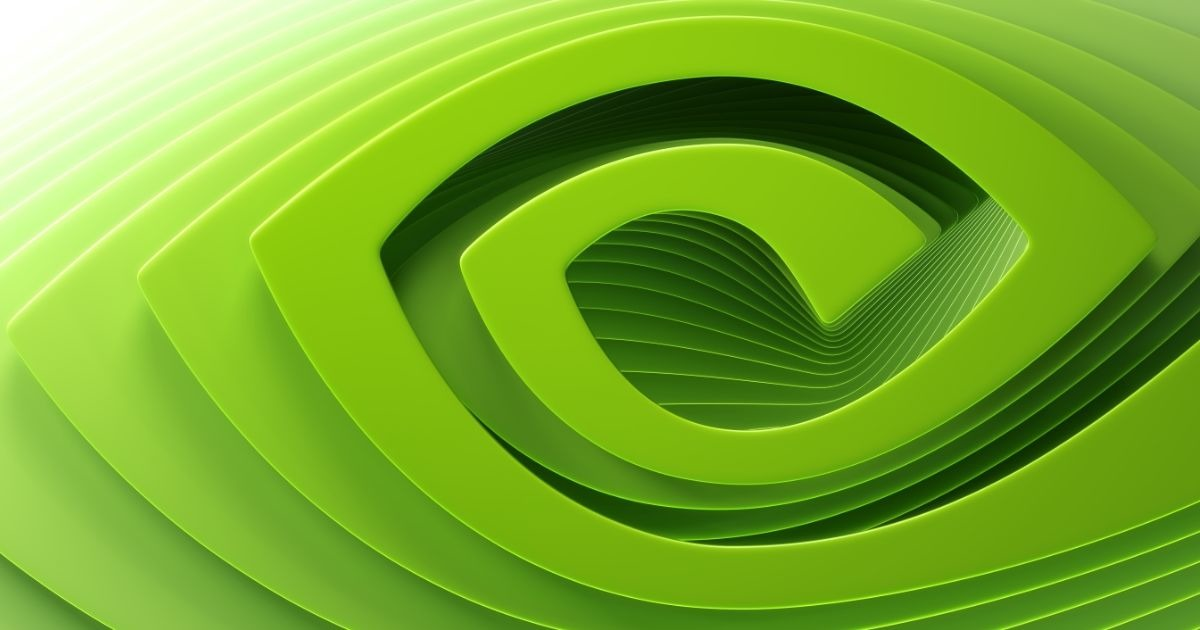

Student: Steven Nguyen 🧑‍🎓

Professor: Yiwei Chen 🧑‍🏫

## **1. Import libraries 📚**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import statsmodels.api as sm

## **2. Load data 📥**

The original dataset link:

https://www.kaggle.com/datasets/jamesanderson23/nvidia-data-for-business-insights

In [36]:
df = pd.read_csv('nvidia_market_analytics.csv')

## **3. Data Libraries 🗃️**

| **Feature**                     | **Description**                                                                               |
| ------------------------------- | --------------------------------------------------------------------------------------------- |
| **Date**                        | Calendar date representing the observation period for sales, marketing, and customer metrics. |
| **Product Category**            | High-level classification of the NVIDIA product (e.g., GPUs, AI hardware, software).          |
| **Product Name**                | Specific name or model of the product being sold (e.g., RTX 4090, A100, Jetson Nano).         |
| **Region**                      | Geographic market where the product was sold (e.g., North America, APAC, Europe).             |
| **Units Sold**                  | Number of product units sold on the given date in the specified region.                       |
| **Customer Segment**            | Target demographic or business group (e.g., Gaming, Data Center, Enterprise).                 |
| **Customer Type**               | Classification such as Individual, SMB, Enterprise, or Government.                            |
| **Customer Satisfaction**       | Customer satisfaction score (e.g., survey-based rating, typically 1–5).               |
| **Marketing Spend (USD)**       | Amount of money invested in marketing activities for the product or region on that date.      |
| **Discount Percentage (%)**     | Percentage price discount offered to customers (e.g., promotions, deals).                     |
| **Competitor Influence**        | Metric indicating competitive pressure (e.g., competitor price cuts, product launches).       |
| **Return Rate (%)**             | Percentage of sold units that were returned by customers.                                     |
| **AI/ML Adoption Rate (%)**     | Percentage of customers adopting AI/ML-related product features or solutions.                 |
| **Ad Campaign Effectiveness**   | Performance measure of marketing campaigns, typically based on ROI or conversion metrics.     |
| **Customer Retention Rate (%)** | Percentage of repeat customers or ongoing client engagements.                                 |
| **Product Launch Date**         | Date when the product model was first released to the market.                                 |
| **Competitor Product**          | Name or classification of competing products affecting NVIDIA’s sales performance.            |
| **Market Share (%)**            | NVIDIA’s share of the total market within the segment or region.                              |
| **Sales Revenue (USD)**         | Total revenue generated from product sales on the given date and region.                      |


In [37]:
df.sample(5)

,Date,Product Category,Product Name,Region,Units Sold,Customer Segment,Customer Type,Customer Satisfaction,Marketing Spend (USD),Discount Percentage (%),Competitor Influence,Return Rate (%),AI/ML Adoption Rate (%),Ad Campaign Effectiveness,Customer Retention Rate (%),Product Launch Date,Competitor Product,Market Share (%),Sales Revenue (USD)
14601,2003-09-27,Gaming,Tesla V100,Africa,857.0,AI Researchers,Individual,1.5,112895.11,6,High,4.18,56.0,0.20,63.0,2020-12-13,AMD Radeon RX 6800,31.83,3.013066e+08
12410,2001-07-10,Gaming,RTX 4090,Africa,2501.0,Gamers,Business,4.6,21258.48,24,Medium,3.98,49.0,0.18,53.0,2020-11-27,AMD Radeon RX 6800,46.36,3.106464e+08
25127,2004-02-02,Gaming,RTX 4090,North America,3880.0,AI Researchers,Individual,2.1,11587.31,23,High,4.74,66.0,0.26,59.0,2016-10-02,Google TPU,49.04,3.176151e+08
26283,2013-09-21,OEM,RTX 3080,APAC,1229.0,Cloud Providers,Individual,5.0,164617.69,2,High,0.54,15.0,0.14,90.0,2021-07-19,AMD Radeon RX 6800,53.49,2.945360e+08
21492,1998-07-05,Gaming,RTX 4090,Europe,2339.0,Cloud Providers,Business,2.4,133162.86,20,High,2.82,32.0,0.07,85.0,2019-12-06,Intel Xeon,46.33,3.030790e+08


## **4. Data profiling 🪄**

In [38]:
df.sample(5)

,Date,Product Category,Product Name,Region,Units Sold,Customer Segment,Customer Type,Customer Satisfaction,Marketing Spend (USD),Discount Percentage (%),Competitor Influence,Return Rate (%),AI/ML Adoption Rate (%),Ad Campaign Effectiveness,Customer Retention Rate (%),Product Launch Date,Competitor Product,Market Share (%),Sales Revenue (USD)
2041,1998-05-23,Gaming,RTX 3080,Middle East,4281.0,Gamers,Individual,3.5,179749.03,8,Low,3.04,29.0,0.17,82.0,2002-01-03,AMD Radeon RX 7900,31.06,3.124145e+08
17533,1997-09-07,Data Center,Tesla T4,North America,4348.0,AI Researchers,Business,3.0,144928.87,14,Medium,3.48,77.0,0.27,87.0,2016-07-03,Google TPU,34.21,3.102168e+08
29113,2011-01-13,Data Center,RTX 4090,Africa,2126.0,AI Researchers,Business,2.1,10637.47,8,High,2.01,21.0,0.08,72.0,2016-10-18,Intel Xeon,48.86,2.823300e+08
3409,2002-11-08,OEM,RTX 4090,Middle East,4173.0,Educational Institutions,Business,1.2,156671.85,24,Medium,4.20,48.0,0.23,68.0,2009-03-18,AMD Radeon RX 6800,68.03,3.039453e+08
19953,2004-08-19,OEM,Quadro P2200,APAC,3816.0,Educational Institutions,Business,4.0,188445.51,21,Low,2.63,25.0,0.21,68.0,2015-03-02,AMD Radeon RX 7900,49.25,3.022653e+08


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         39297 non-null  object 
 1   Product Category             39298 non-null  object 
 2   Product Name                 39296 non-null  object 
 3   Region                       39298 non-null  object 
 4   Units Sold                   39296 non-null  float64
 5   Customer Segment             39296 non-null  object 
 6   Customer Type                39296 non-null  object 
 7   Customer Satisfaction        39297 non-null  float64
 8   Marketing Spend (USD)        39296 non-null  float64
 9   Discount Percentage (%)      39298 non-null  int64  
 10  Competitor Influence         39297 non-null  object 
 11  Return Rate (%)              39297 non-null  float64
 12  AI/ML Adoption Rate (%)      39297 non-null  float64
 13  Ad Campaign Effe

In [40]:
df.describe()

,Units Sold,Customer Satisfaction,Marketing Spend (USD),Discount Percentage (%),Return Rate (%),AI/ML Adoption Rate (%),Ad Campaign Effectiveness,Customer Retention Rate (%),Market Share (%),Sales Revenue (USD)
count,39296.000000,39297.000000,39296.000000,39298.000000,39297.000000,39297.000000,39297.000000,39296.000000,39298.000000,3.929800e+04
mean,2545.893043,3.000428,105293.127468,12.427655,2.543982,50.155584,0.175093,69.928390,49.984228,4.138194e+10
std,1414.499953,1.155193,54876.621143,7.481265,1.410405,23.460934,0.072053,11.848559,11.602159,1.485058e+11
min,100.000000,1.000000,10002.090000,0.000000,0.100000,10.000000,0.050000,50.000000,30.000000,2.800031e+08
25%,1326.000000,2.000000,57844.167500,6.000000,1.330000,30.000000,0.110000,60.000000,39.910000,2.936473e+08
50%,2532.000000,3.000000,105158.110000,12.000000,2.540000,50.000000,0.170000,70.000000,50.040000,3.074508e+08
75%,3781.000000,4.000000,152840.597500,19.000000,3.760000,70.000000,0.240000,80.000000,60.070000,1.206214e+09
max,5000.000000,5.000000,199996.890000,25.000000,5.000000,90.000000,0.300000,90.000000,70.000000,1.119958e+12


## **5. Data cleaning 🧹**

### 5.1 Name changing for coding-friendly

In [41]:
df.columns

Index(['Date', 'Product Category', 'Product Name', 'Region', 'Units Sold',
       'Customer Segment', 'Customer Type', 'Customer Satisfaction',
       'Marketing Spend (USD)', 'Discount Percentage (%)',
       'Competitor Influence', 'Return Rate (%)', 'AI/ML Adoption Rate (%)',
       'Ad Campaign Effectiveness', 'Customer Retention Rate (%)',
       'Product Launch Date', 'Competitor Product', 'Market Share (%)',
       'Sales Revenue (USD)'],
      dtype='object')

In [42]:
df_1 = df.copy()

df_1.columns = [col.replace(' ', '') for col in df.columns]

Check again

In [43]:
df_1.columns

Index(['Date', 'ProductCategory', 'ProductName', 'Region', 'UnitsSold',
       'CustomerSegment', 'CustomerType', 'CustomerSatisfaction',
       'MarketingSpend(USD)', 'DiscountPercentage(%)', 'CompetitorInfluence',
       'ReturnRate(%)', 'AI/MLAdoptionRate(%)', 'AdCampaignEffectiveness',
       'CustomerRetentionRate(%)', 'ProductLaunchDate', 'CompetitorProduct',
       'MarketShare(%)', 'SalesRevenue(USD)'],
      dtype='object')

### 5.2 Change Data Type

In [44]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      39297 non-null  object 
 1   ProductCategory           39298 non-null  object 
 2   ProductName               39296 non-null  object 
 3   Region                    39298 non-null  object 
 4   UnitsSold                 39296 non-null  float64
 5   CustomerSegment           39296 non-null  object 
 6   CustomerType              39296 non-null  object 
 7   CustomerSatisfaction      39297 non-null  float64
 8   MarketingSpend(USD)       39296 non-null  float64
 9   DiscountPercentage(%)     39298 non-null  int64  
 10  CompetitorInfluence       39297 non-null  object 
 11  ReturnRate(%)             39297 non-null  float64
 12  AI/MLAdoptionRate(%)      39297 non-null  float64
 13  AdCampaignEffectiveness   39297 non-null  float64
 14  Custom

#### 5.2.1 Change date data to "datetime" type

In [45]:
datetime_cols = ['Date', 'ProductLaunchDate']

for col in datetime_cols:
    df_1[col] = pd.to_datetime(df_1[col], format='%Y-%m-%d', errors='coerce')
    print(f"  -> Converted '{col}' to datetime.")

  -> Converted 'Date' to datetime.
  -> Converted 'ProductLaunchDate' to datetime.


Check again:

In [46]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      39297 non-null  datetime64[ns]
 1   ProductCategory           39298 non-null  object        
 2   ProductName               39296 non-null  object        
 3   Region                    39298 non-null  object        
 4   UnitsSold                 39296 non-null  float64       
 5   CustomerSegment           39296 non-null  object        
 6   CustomerType              39296 non-null  object        
 7   CustomerSatisfaction      39297 non-null  float64       
 8   MarketingSpend(USD)       39296 non-null  float64       
 9   DiscountPercentage(%)     39298 non-null  int64         
 10  CompetitorInfluence       39297 non-null  object        
 11  ReturnRate(%)             39297 non-null  float64       
 12  AI/MLAdoptionRate(

#### 5.2.2 Change categorical data to "category" type

In [47]:
for col in df_1:
  if df_1[col].dtype == 'object':
    df_1[col] = df_1[col].astype('category')

Check again:

In [48]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      39297 non-null  datetime64[ns]
 1   ProductCategory           39298 non-null  category      
 2   ProductName               39296 non-null  category      
 3   Region                    39298 non-null  category      
 4   UnitsSold                 39296 non-null  float64       
 5   CustomerSegment           39296 non-null  category      
 6   CustomerType              39296 non-null  category      
 7   CustomerSatisfaction      39297 non-null  float64       
 8   MarketingSpend(USD)       39296 non-null  float64       
 9   DiscountPercentage(%)     39298 non-null  int64         
 10  CompetitorInfluence       39297 non-null  category      
 11  ReturnRate(%)             39297 non-null  float64       
 12  AI/MLAdoptionRate(

### 5.3 Hanndling N/A values

#### 5.3.1 Checking empty rows

In [49]:
df_1.isnull().sum().sort_values(ascending=False)

,0
ProductName,2
CustomerSegment,2
UnitsSold,2
CustomerRetentionRate(%),2
MarketingSpend(USD),2
CustomerType,2
Date,1
ProductLaunchDate,1
CompetitorInfluence,1
ReturnRate(%),1


#### 5.3.2 Fill values in column with empty rows

Create a function that fills every N/A values in each columns

In [50]:
from typing import Dict, Any

def impute_missing_values_inplace(df: pd.DataFrame) -> None:

    # 1. Separate columns by data type
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols = df.select_dtypes(include=['category']).columns
    datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns

    print(f"✅ Starting IN-PLACE imputation for DataFrame with {len(df)} rows.")
    print("-" * 50)

    # 2. Impute Numeric Columns (using Median)
    print(f"⏳ Imputing {len(numeric_cols)} numeric columns with the **Median**...")
    for col in numeric_cols:
        # Calculate median only if there are missing values
        if df[col].isnull().any():
            median_val = df[col].median()
            # The 'inplace=True' argument is used here to modify the DataFrame directly
            df[col].fillna(median_val, inplace=True)
    print("   -> Numeric imputation complete.")

    # 3. Impute Categorical and Datetime Columns (using Mode)
    mode_cols = list(categorical_cols) + list(datetime_cols)
    print(f"\n⏳ Imputing {len(mode_cols)} categorical/datetime columns with the **Mode**...")
    for col in mode_cols:
        if df[col].isnull().any():
            # Get the mode (most frequent value)
            mode_val = df[col].mode()[0]
            # Fill NaNs/NaTs in place
            df[col].fillna(mode_val, inplace=True)
    print("   -> Categorical/Datetime imputation complete.")

    print("-" * 50)
    print("✨ Imputation successful!")
    print("\nVerifying non-null counts after imputation (df.info()):")
    df.info()

Imputing all the missing values

In [51]:
impute_missing_values_inplace(df_1)

✅ Starting IN-PLACE imputation for DataFrame with 39298 rows.
--------------------------------------------------
⏳ Imputing 10 numeric columns with the **Median**...
   -> Numeric imputation complete.

⏳ Imputing 9 categorical/datetime columns with the **Mode**...
   -> Categorical/Datetime imputation complete.
--------------------------------------------------
✨ Imputation successful!

Verifying non-null counts after imputation (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      39298 non-null  datetime64[ns]
 1   ProductCategory           39298 non-null  category      
 2   ProductName               39298 non-null  category      
 3   Region                    39298 non-null  category      
 4   UnitsSold                 39298 non-null  float64       
 5   Custom

/tmp/ipython-input-2796023008.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-2796023008.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

Check again

In [52]:
df_1.isnull().sum().sort_values(ascending=False)

,0
Date,0
ProductCategory,0
ProductName,0
Region,0
UnitsSold,0
CustomerSegment,0
CustomerType,0
CustomerSatisfaction,0
MarketingSpend(USD),0
DiscountPercentage(%),0


### 5.4 Find duplicates

In [53]:
all_dupliactes = df_1.duplicated().sum()
print("🔁 Recoreded duplicates found:", all_dupliactes)

🔁 Recoreded duplicates found: 0


=> There is no duplicate to be handled

## **6. EDA (Exploratory Data Analysis) 🔬**

### 6.1 Average Units Sold by Product Category

/tmp/ipython-input-3744217392.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_units = df_1.groupby("ProductCategory")["UnitsSold"].mean().reset_index()


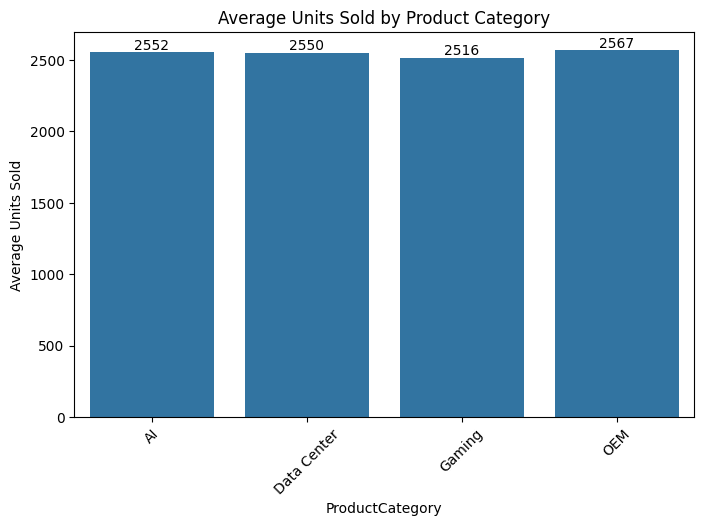

In [54]:
avg_units = df_1.groupby("ProductCategory")["UnitsSold"].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="ProductCategory",
    y="UnitsSold",
    data=avg_units
)

plt.title("Average Units Sold by Product Category")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

* The OEM (Original Equipment Manufacturer) has the highest average units sold at 2,567 units.

* Among the categories, there are no signifcant difference between the product category

### 6.2 Units Sold over time with values

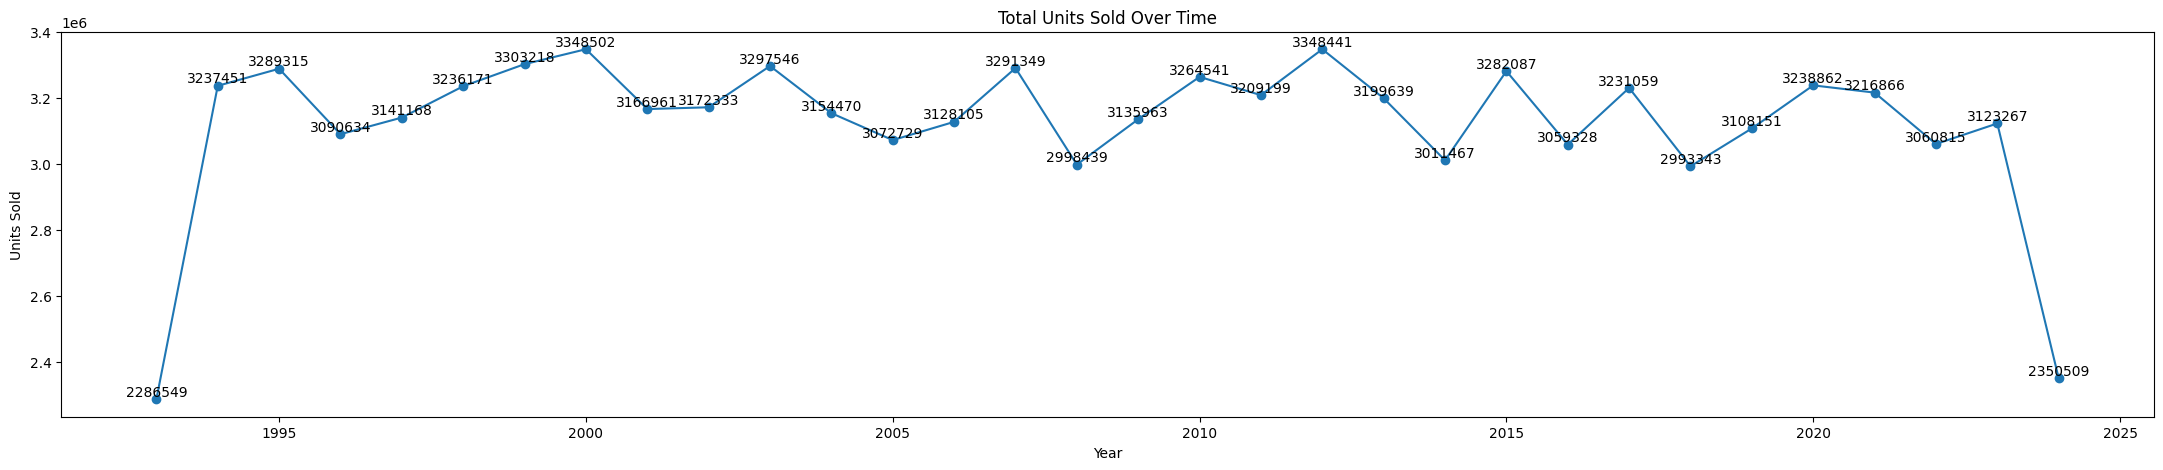

In [55]:
df_1["Year"] = df_1["Date"].dt.year
units_year = df_1.groupby("Year")["UnitsSold"].sum()
plt.figure(figsize=(27,5))
ax = units_year.plot(marker="o")
plt.title("Total Units Sold Over Time")
plt.ylabel("Units Sold")
for x, y in zip(units_year.index, units_year.values):
    plt.text(x, y, f"{int(y)}", ha="center", va="bottom")

plt.show()

* Total units sold over the time show the high volatility with the peak reaching the maximum of 3,348,441 units in 2012.

* Prominently it dropped significantly in 2024 with 2,357,509 units

### 6.3 Time Series Analysis

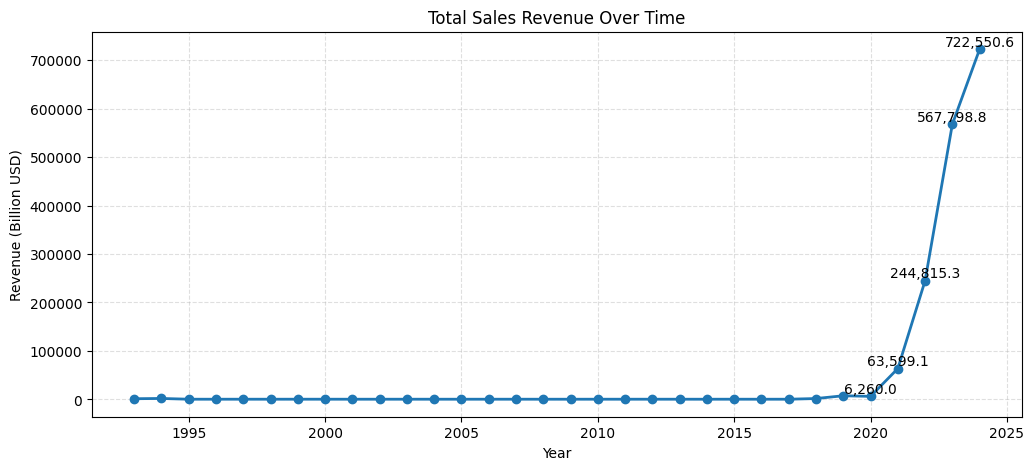

In [56]:
revenue_time = df_1.groupby("Year")["SalesRevenue(USD)"].sum() / 1e9

plt.figure(figsize=(12,5))
ax = revenue_time.plot(marker="o", linewidth=2)

plt.title("Total Sales Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (Billion USD)")

# Add labels ONLY from 2020 to 2025
for x, y in zip(revenue_time.index, revenue_time.values):
    if 2020 <= x <= 2025:
        plt.text(x, y, f"{y:,.1f}", ha="center", va="bottom")

ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

* Despite the total units sold drop, the total sales revenue skyrocketed exponentially from 2010 to 2024. It recoreded the highest sales revenue of `$722,550.6`

### 6.4 Average Revenue by Region

/tmp/ipython-input-1817516053.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rev_region = df_1.groupby("Region")["SalesRevenue(USD)"].mean().reset_index()


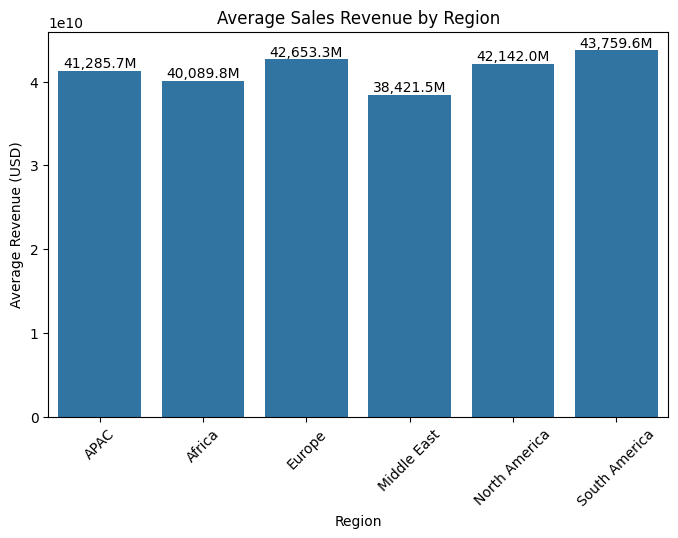

In [57]:
avg_rev_region = df_1.groupby("Region")["SalesRevenue(USD)"].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="Region",
    y="SalesRevenue(USD)",
    data=avg_rev_region
)

plt.title("Average Sales Revenue by Region")
plt.ylabel("Average Revenue (USD)")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()/1e6:,.1f}M",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()


* Average Sales Revenue shows the highest values in South America at `$43,759.6M`. The lowest we can see is the Middle East with `$38,421.5M`.

* Across the regions, the revenue ranges from 40 to 43 millions dollars which again distributes quite evenly.

### 6.5 Average Market Share by Product Category

/tmp/ipython-input-2971633496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_1.groupby("ProductCategory")["SalesRevenue(USD)"]


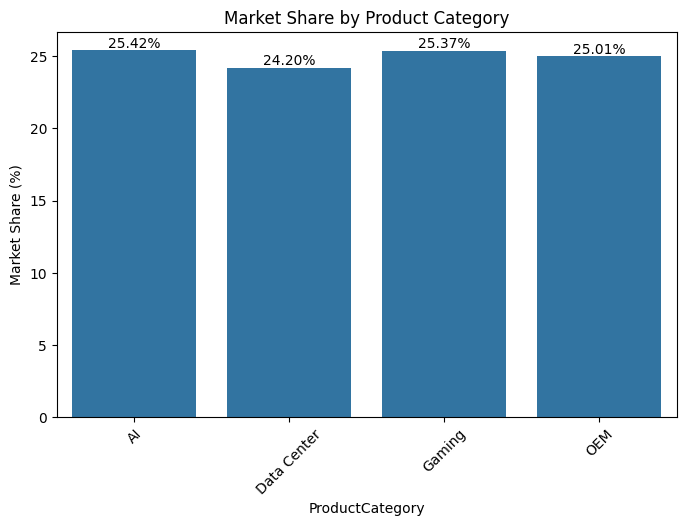

In [58]:
category_revenue = (
    df_1.groupby("ProductCategory")["SalesRevenue(USD)"]
    .sum()
    .reset_index()
)

total_revenue = category_revenue["SalesRevenue(USD)"].sum()

category_revenue["MarketShare(%)"] = (
    category_revenue["SalesRevenue(USD)"] / total_revenue * 100
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="ProductCategory",
    y="MarketShare(%)",
    data=category_revenue
)

plt.title("Market Share by Product Category")
plt.ylabel("Market Share (%)")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()


* All the categories will lies within the range of 24% and 25%. It shows that the need for the Nvidia's technologies from acorss industry is very simlilar.

### 6.6 Sales Revenue by Year comparision (Before and After 2020)

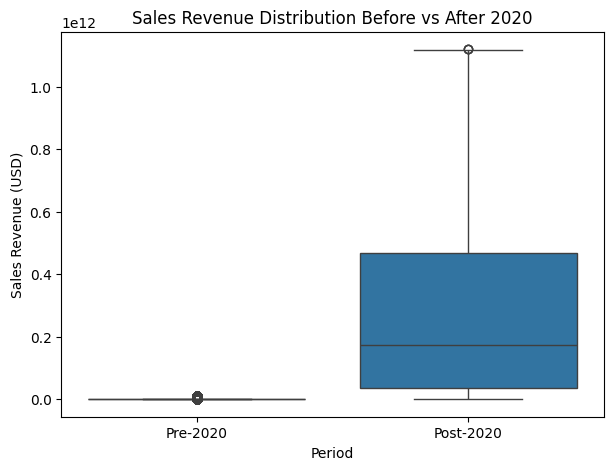

In [59]:
df_1["Period"] = df_1["Year"].apply(lambda x: "Pre-2020" if x < 2020 else "Post-2020")

plt.figure(figsize=(7,5))
sns.boxplot(
    x="Period",
    y="SalesRevenue(USD)",
    data=df_1
)

plt.title("Sales Revenue Distribution Before vs After 2020")
plt.xlabel("Period")
plt.ylabel("Sales Revenue (USD)")
plt.show()


* We can see the post 2020 has a bigger spread which explains the sudden growth in Invidia's sales which eventually leads the distribution to skew to the

## **7. Convert Categorical data to Numeric ⚙️**

In [60]:
# 1. Identify all columns with the 'category' Dtype
# This is the correct dtype to target based on your previous steps.
category_cols = df_1.select_dtypes(include='category').columns.tolist()

if not category_cols:
    print("⚠️ No 'category' data type columns found in df_1. Encoding skipped.")
else:
    print(f"✅ Starting One-Hot Encoding (drop_first=True) for the following {len(category_cols)} columns:")
    print(category_cols)

    # 2. Apply One-Hot Encoding using pd.get_dummies()
    # The result is assigned to a new DataFrame named 'df_encoded'.
    df_encoded = pd.get_dummies(df_1, columns=category_cols, drop_first=True )

✅ Starting One-Hot Encoding (drop_first=True) for the following 7 columns:
['ProductCategory', 'ProductName', 'Region', 'CustomerSegment', 'CustomerType', 'CompetitorInfluence', 'CompetitorProduct']


Check again

In [61]:
df_encoded.head()

,Date,UnitsSold,CustomerSatisfaction,MarketingSpend(USD),DiscountPercentage(%),ReturnRate(%),AI/MLAdoptionRate(%),AdCampaignEffectiveness,CustomerRetentionRate(%),ProductLaunchDate,...,Region_South America,CustomerSegment_Cloud Providers,CustomerSegment_Educational Institutions,CustomerSegment_Gamers,CustomerType_Individual,CompetitorInfluence_Low,CompetitorInfluence_Medium,CompetitorProduct_AMD Radeon RX 7900,CompetitorProduct_Google TPU,CompetitorProduct_Intel Xeon
0,2016-08-12,3758.0,1.9,155181.38,8,1.33,12.0,0.22,63.0,2018-10-27,...,False,False,False,True,True,True,False,True,False,False
1,1995-07-02,4978.0,4.2,136191.16,19,2.69,75.0,0.28,88.0,2021-07-22,...,False,True,False,False,True,False,True,True,False,False
2,2019-05-08,1875.0,1.3,156854.40,10,4.12,10.0,0.28,80.0,2017-04-18,...,False,False,False,False,False,True,False,True,False,False
3,2008-06-26,3551.0,3.8,79772.88,5,4.69,43.0,0.13,72.0,2001-06-16,...,False,True,False,False,True,True,False,False,False,True
4,1996-07-17,1571.0,4.0,165636.07,15,0.58,48.0,0.12,63.0,2000-01-04,...,False,False,False,False,False,False,True,False,True,False


In [62]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39298 entries, 0 to 39297
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      39298 non-null  datetime64[ns]
 1   UnitsSold                                 39298 non-null  float64       
 2   CustomerSatisfaction                      39298 non-null  float64       
 3   MarketingSpend(USD)                       39298 non-null  float64       
 4   DiscountPercentage(%)                     39298 non-null  int64         
 5   ReturnRate(%)                             39298 non-null  float64       
 6   AI/MLAdoptionRate(%)                      39298 non-null  float64       
 7   AdCampaignEffectiveness                   39298 non-null  float64       
 8   CustomerRetentionRate(%)                  39298 non-null  float64       
 9   ProductLaunchDate           

## **8. Correlations Model 📊**

In [63]:
correlation_matrix = df_encoded.drop(columns=['Period', 'Year']).corr()

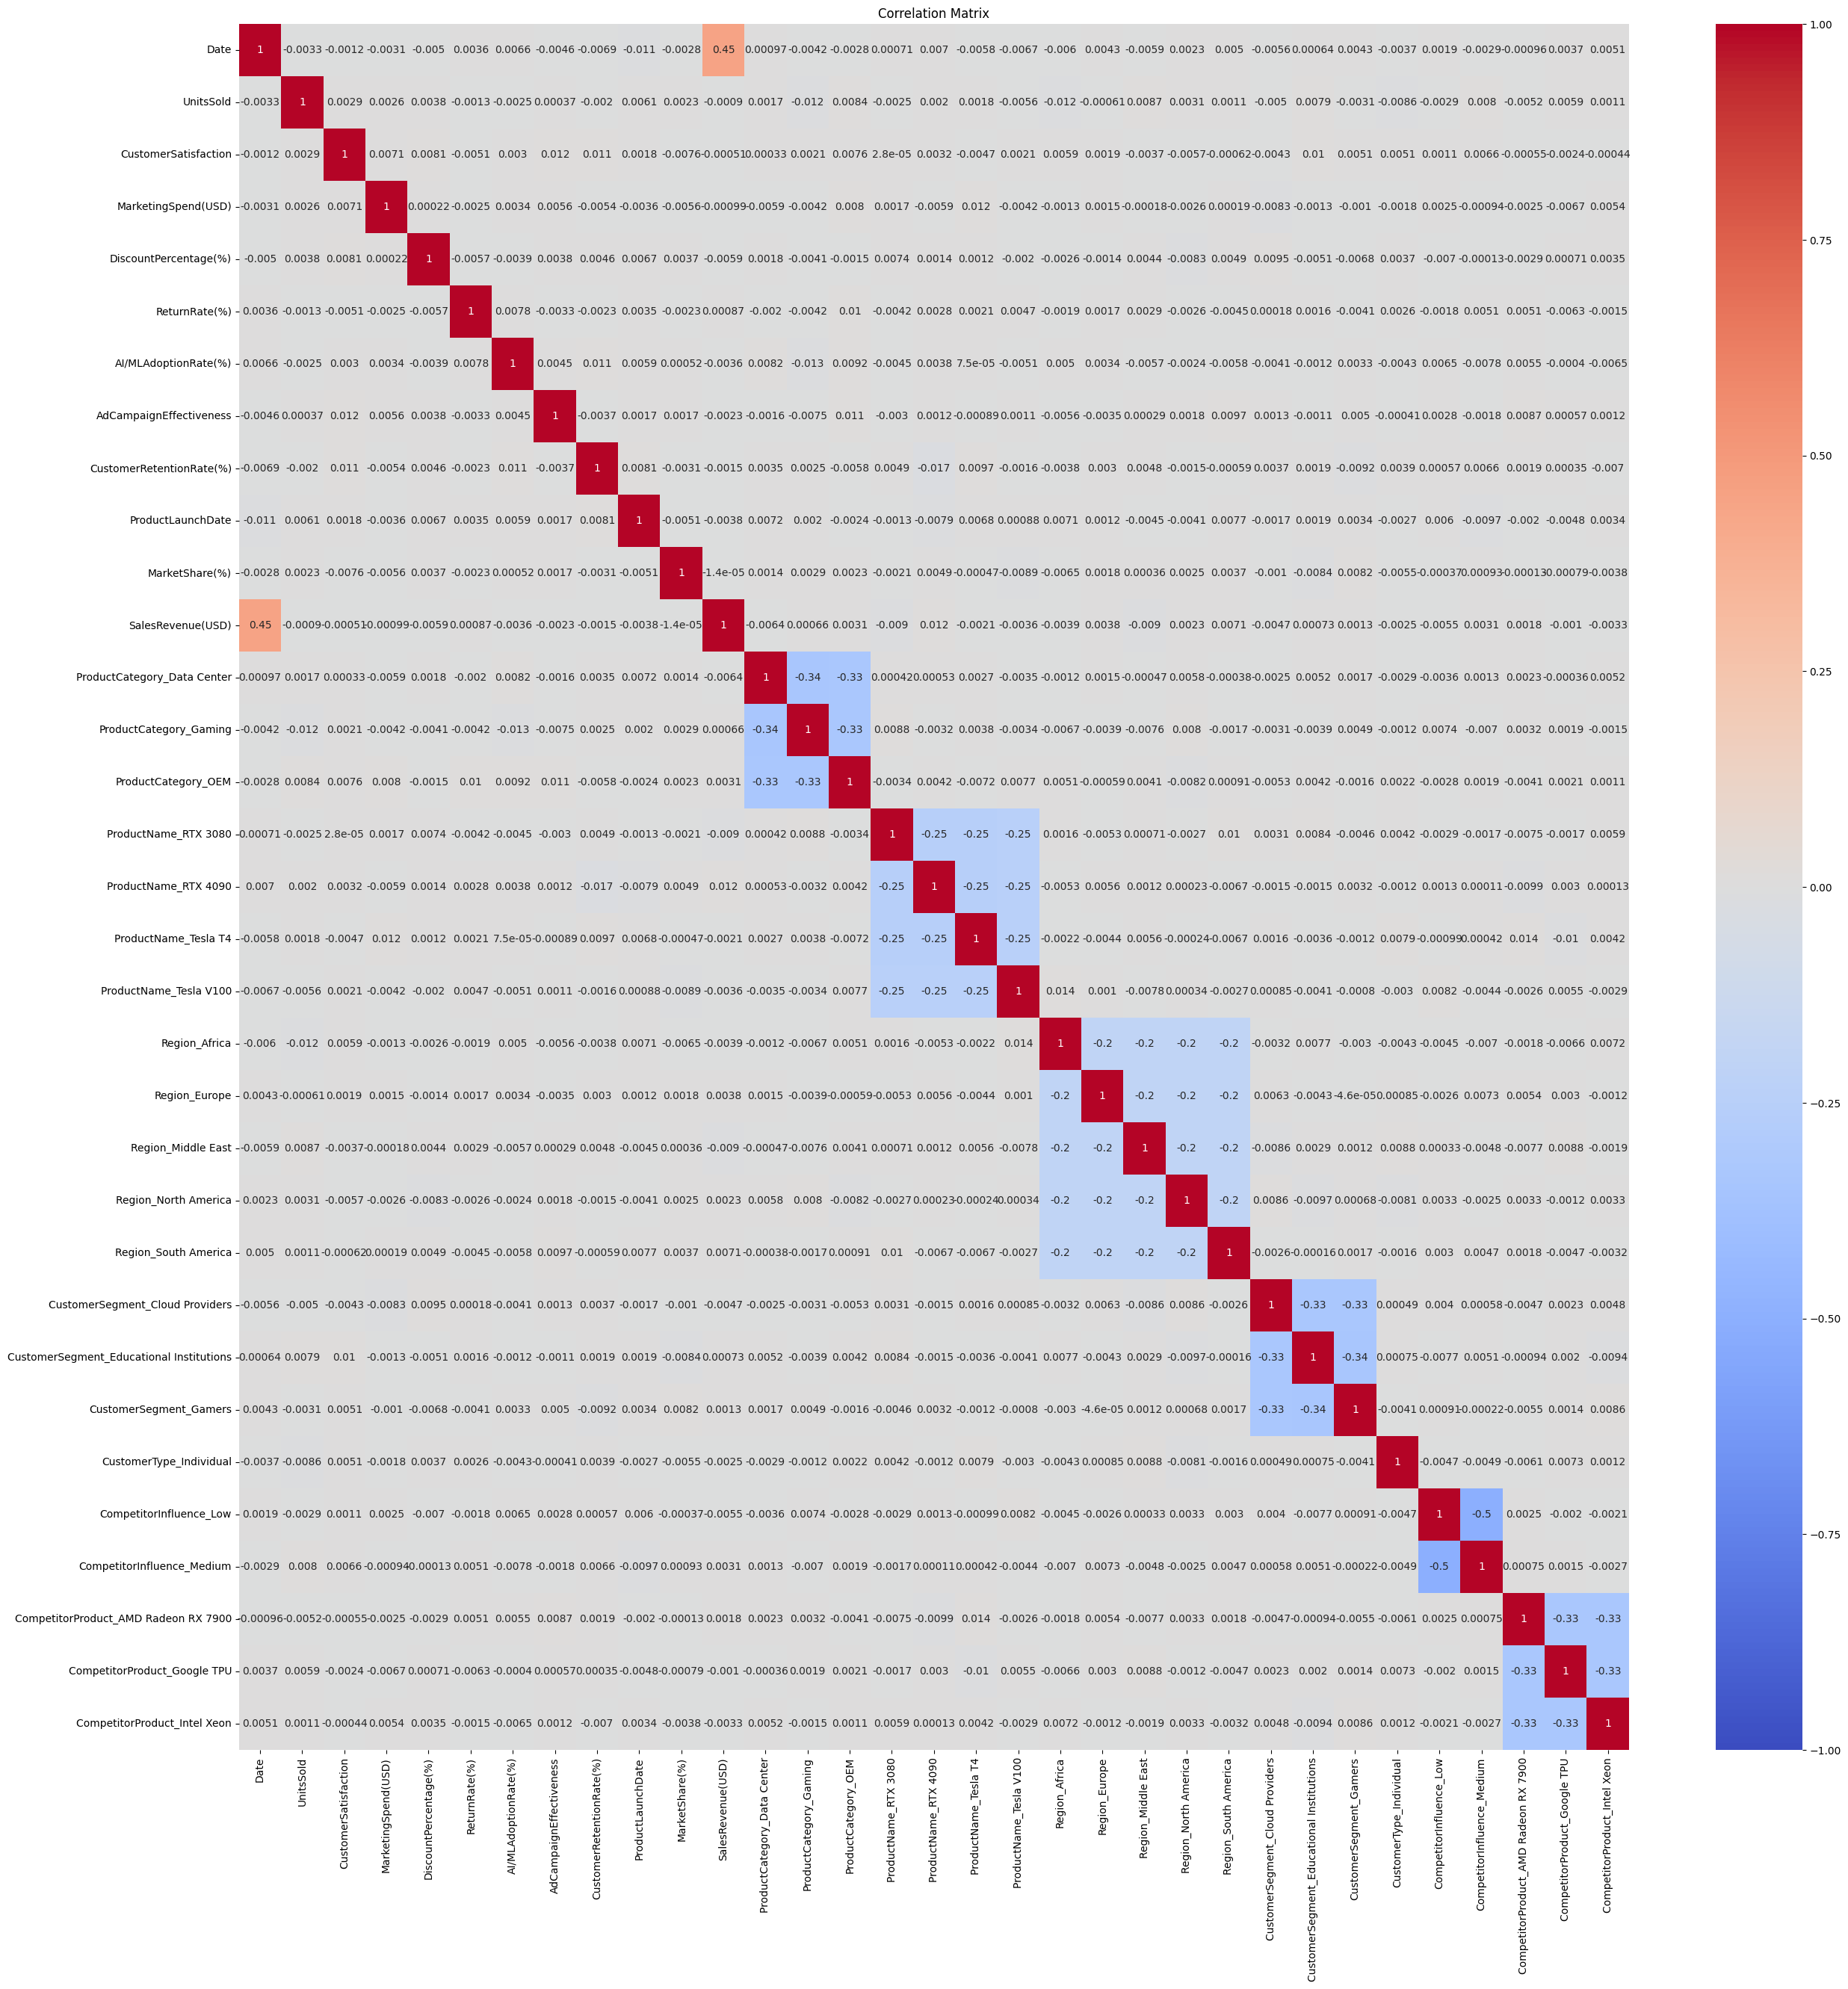

In [64]:
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## **9. Build a linear regression model 🧮**


In [65]:
x = df_encoded[[
    # Core numeric drivers
    'UnitsSold',
    'CustomerSatisfaction',
    'MarketingSpend(USD)',
    'DiscountPercentage(%)',
    'ReturnRate(%)',
    'AI/MLAdoptionRate(%)',
    'AdCampaignEffectiveness',
    'CustomerRetentionRate(%)',
    'MarketShare(%)',

    # Product Category
    'ProductCategory_Data Center',
    'ProductCategory_Gaming',
    'ProductCategory_OEM',

    # Product Name
    'ProductName_RTX 3080',
    'ProductName_RTX 4090',
    'ProductName_Tesla T4',
    'ProductName_Tesla V100',

    # Region
    'Region_Africa',
    'Region_Europe',
    'Region_Middle East',
    'Region_North America',
    'Region_South America',

    # Customer Segment
    'CustomerSegment_Cloud Providers',
    'CustomerSegment_Educational Institutions',
    'CustomerSegment_Gamers',

    # Customer Type
    'CustomerType_Individual',

    # Competitor Influence
    'CompetitorInfluence_Low',
    'CompetitorInfluence_Medium',

    # Competitor Products
    'CompetitorProduct_AMD Radeon RX 7900',
    'CompetitorProduct_Google TPU',
    'CompetitorProduct_Intel Xeon'
]].copy()

y = df_encoded['SalesRevenue(USD)']

# Convert boolean columns to integers (0 or 1)
bool_cols = x.select_dtypes(include='bool').columns
x[bool_cols] = x[bool_cols].astype(int)

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      SalesRevenue(USD)   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6736
Date:                Sat, 13 Dec 2025   Prob (F-statistic):              0.911
Time:                        04:03:13   Log-Likelihood:            -1.0666e+06
No. Observations:               39298   AIC:                         2.133e+06
Df Residuals:                   39267   BIC:                         2.134e+06
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

## **10. Adjust model 🖊️**



In [66]:
x = df_encoded[[
    # Product Category
    'ProductName_RTX 4090'
]].copy()

y = df_encoded['SalesRevenue(USD)']

# Convert boolean columns to integers (0 or 1)
bool_cols = x.select_dtypes(include='bool').columns
x[bool_cols] = x[bool_cols].astype(int)

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      SalesRevenue(USD)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     5.682
Date:                Sat, 13 Dec 2025   Prob (F-statistic):             0.0171
Time:                        04:03:13   Log-Likelihood:            -1.0667e+06
No. Observations:               39298   AIC:                         2.133e+06
Df Residuals:                   39296   BIC:                         2.133e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4.048e+10 

After I remove varibles with  insignifcant P-Value, I am left with ProductName_RTX 4090, Which could tell me the reason why nvidia sales went up extremely high. But the R-squared is only 0% so this simple linear regression model is not ideal to catch all the predictors. More data science works should be taken to solve this matter  

## **11. Final Conclusion ✅**

* Unit sold are relatively stable at tall time which suggests the mature and steady demand from the market except for the 2024. This signifies the company may have shifted to other product when the total units fell but the sales grew noticably in 2024.

* Regional average revenue is highest in North and South America. These are key regions, the board can focus on allocating more budget like marketing expense to these areas and increase their operations as well.

* When it comes to experimenting the regression model. The simple linear regression cannot explain the entire complex relatioship between varibales with sales revenue. So there are posibility, Invidia can focus more on the machine learning and data science to reap more business insights and reinforce their competitive strength.

## **12. Export file 📤**

In [67]:
df_1.to_csv("nvidia_market_analytics_processed.csv", index=False)
print(f"The file has been exported successfully ✅")

The file has been exported successfully ✅
